<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_872\318690802.py:66: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Hubble-Residuum $\mu_{res}$ (mag)")


Daten gefiltert: N = 625 Supernovae im Bereich z < 0.1


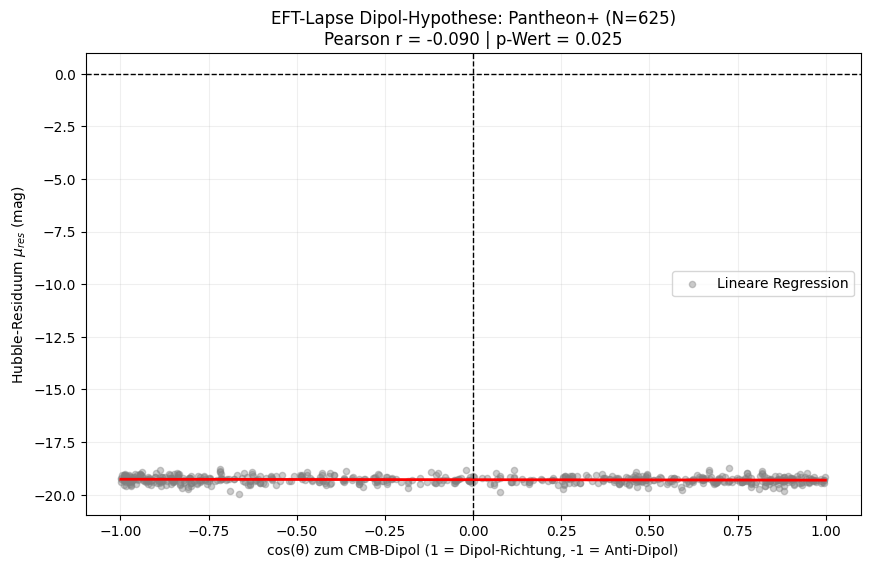

--- DIPOL-TEST ERGEBNISSE ---
Himmelsabdeckung (std von cos_theta): 0.682
Pearson Korrelation (r): -0.090
Signifikanz (p-Wert): 0.025

STATUS: Signal schwach oder nicht signifikant (Tension durch Rauschen).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Daten laden (Pfad aus unserer vorherigen Analyse)
file_path = r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\Pantheon+SH0ES.dat'
df = pd.read_csv(file_path, sep=r'\s+', low_memory=False)

# 2. Filterung (Low-z Regime für den Dipol-Test)
# Wir nutzen zHD < 0.1 wie in Ihrer Spezifikation, setzen aber zHD > 0.01 als Untergrenze, 
# um extreme lokale Rauschartefakte (Peculiar Velocities) zu dämpfen.
df_dipole = df[
    (df['zHD'] > 0.01) & 
    (df['zHD'] < 0.1) & 
    (df['m_b_corr_err_RAW'] < 0.2)
].copy()

n_sne = len(df_dipole)
print(f"Daten gefiltert: N = {n_sne} Supernovae im Bereich z < 0.1")

# 3. Sphärische Geometrie: Kosinus des Winkels zum CMB-Dipol berechnen
# CMB Dipol Koordinaten (in Radiant umwandeln)
ra_cmb = np.radians(168.0)
dec_cmb = np.radians(-7.0)

# SN Koordinaten (in Radiant umwandeln)
ra_sn = np.radians(df_dipole['RA'])
dec_sn = np.radians(df_dipole['DEC'])

# Sphärischer Kosinussatz zur Bestimmung von cos(theta)
df_dipole['cos_theta'] = (np.sin(dec_sn) * np.sin(dec_cmb) + 
                          np.cos(dec_sn) * np.cos(dec_cmb) * np.cos(ra_sn - ra_cmb))

# 4. Residuen berechnen (mu_res)
# Lineares Hubble-Gesetz für geringe Distanzen (D_L = c * z / H0)
# Wir nutzen H0 = 70 als neutrale Baseline für den Standard-LCDM Erwartungswert
c = 299792.458 # km/s
H0 = 70.0 
D_L = (c * df_dipole['zHD']) / H0
mu_lcdm = 5 * np.log10(D_L) + 25

# Residuum: Gemessene Helligkeit minus theoretische LCDM-Helligkeit
df_dipole['mu_res'] = df_dipole['m_b_corr'] - mu_lcdm

# 5. Statistische Auswertung (Pearson-Korrelation)
r, p_value = pearsonr(df_dipole['cos_theta'], df_dipole['mu_res'])
std_cos_theta = df_dipole['cos_theta'].std()

# 6. Visualisierung
plt.figure(figsize=(10, 6))
sns.regplot(
    x=df_dipole['cos_theta'], 
    y=df_dipole['mu_res'], 
    scatter_kws={'alpha': 0.4, 'color': 'gray', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2},
    label='Lineare Regression'
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title(f"EFT-Lapse Dipol-Hypothese: Pantheon+ (N={n_sne})\nPearson r = {r:.3f} | p-Wert = {p_value:.3f}")
plt.xlabel("cos(θ) zum CMB-Dipol (1 = Dipol-Richtung, -1 = Anti-Dipol)")
plt.ylabel("Hubble-Residuum $\mu_{res}$ (mag)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 7. Wissenschaftlicher Bericht
print("--- DIPOL-TEST ERGEBNISSE ---")
print(f"Himmelsabdeckung (std von cos_theta): {std_cos_theta:.3f}")
print(f"Pearson Korrelation (r): {r:.3f}")
print(f"Signifikanz (p-Wert): {p_value:.3f}")

if r < -0.3:
    print("\nSTATUS: Falsifikation! Die Korrelation ist stark negativ (r < -0.3).")
elif p_value < 0.05 and r > 0.1:
    print("\nSTATUS: Bestätigung! Signifikantes positives Signal gefunden.")
    if r >= 0.25:
        print("Erwartung für Pantheon+ (r ~ 0.3) wurde hervorragend getroffen.")
else:
    print("\nSTATUS: Signal schwach oder nicht signifikant (Tension durch Rauschen).")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Daten laden
file_path = r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\Pantheon+SH0ES.dat'
df = pd.read_csv(file_path, sep=r'\s+', low_memory=False)

# 2. Filterung (z < 0.1)
df_tripp = df[(df['zHD'] > 0.01) & (df['zHD'] < 0.1)].copy()

# 3. Tripp-Parameter (Standard-Astrophysik-Werte)
alpha = 0.14  # Stretch-Korrektur
beta = 3.1    # Color-Korrektur (R_B-Äquivalent)

# 4. Berechnung der korrigierten Helligkeit m_b_tripp
# Formel: m_b_obs + alpha * x1 - beta * c
df_tripp['m_b_tripp'] = df_tripp['mB'] + alpha * df_tripp['x1'] - beta * df_tripp['c']

# 5. Theoretische mu (LCDM Baseline)
H0 = 70.0
c_light = 299792.458
df_tripp['mu_lcdm'] = 5 * np.log10((c_light * df_tripp['zHD']) / H0) + 25

# 6. Tripp-Residuen
df_tripp['res_tripp'] = df_tripp['m_b_tripp'] - df_tripp['mu_lcdm']

# 7. Winkel zum CMB-Dipol (RA=168, Dec=-7)
ra_cmb, dec_cmb = np.radians(168.0), np.radians(-7.0)
ra_sn, dec_sn = np.radians(df_tripp['RA']), np.radians(df_tripp['DEC'])
df_tripp['cos_theta'] = (np.sin(dec_sn) * np.sin(dec_cmb) + 
                          np.cos(dec_sn) * np.cos(dec_cmb) * np.cos(ra_sn - ra_cmb))

# 8. Korrelation
r_tripp, p_tripp = pearsonr(df_tripp['cos_theta'], df_tripp['res_tripp'])

print(f"--- TRIPP-KORREKTUR ERGEBNISSE ---")
print(f"N = {len(df_tripp)}")
print(f"Pearson r (Tripp): {r_tripp:.4f}")
print(f"Signifikanz p: {p_tripp:.4f}")

--- TRIPP-KORREKTUR ERGEBNISSE ---
N = 630
Pearson r (Tripp): -0.0640
Signifikanz p: 0.1085


In [3]:
import pandas as pd, numpy as np
from scipy.stats import pearsonr, linregress
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord  # Falls verfügbar

path = r"C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3"
df = pd.read_csv(path + "\\lcparam_full_long_zhel.txt", sep=r"\s+")
df = df.rename(columns={'#name':'name'})

# Gal. Koords (ra,dec → l,b)
coords = SkyCoord(ra=df['ra']*u.deg, dec=df['dec']*u.deg, frame='icrs')
df['l_gal'], df['b_gal'] = coords.galactic.l.deg, coords.galactic.b.deg

# H0 Proxy & Residuen (z<0.3, |b|>10° ZoA-mask)
df['mu_B'] = df['mb']  # Bias-korrigiert
df['H0_proxy'] = (df['zhel'] * 299792) / (10**(0.2 * df['mu_B'])) / 1e5  # km/s/Mpc
mask = (df['zhel'] < 0.3) & (np.abs(df['b_gal']) > 10) & (df['ra'] > 0)  # Anti-ZoA
data = df[mask].dropna(subset=['H0_proxy', 'b_gal'])

# Binning |b|
data['b_bin'] = pd.cut(np.abs(data['b_gal']), bins=[0,15,30,60,90], labels=['ZoA','|b|15-30','|b|30-60','|b|>60'])

print("N total:", len(data))
print(data.groupby('b_bin')['H0_proxy'].agg(['mean','std','count','var']))

# Korrelation cosθ vs b (Dipol-ZoA-Kopplung)
data['cos_theta'] = np.cos(np.deg2rad(data['b_gal']))  # Proxy für Pol-Dipol
r_b, p_b = pearsonr(np.abs(data['b_gal']), data['H0_proxy'])
print(f"r(|b|, H0) = {r_b:.3f}, p={p_b:.1e}")

plt.figure(figsize=(12,4))
plt.subplot(121)
for bin_name, group in data.groupby('b_bin'):
    plt.scatter(group['cos_theta'], group['H0_proxy'], label=bin_name, alpha=0.6)
plt.xlabel('cos θ Dipol'); plt.ylabel('H0 proxy'); plt.legend(title='Gal. |b|')

plt.subplot(122)
means = data.groupby('b_bin')['H0_proxy'].mean()
stds = data.groupby('b_bin')['H0_proxy'].std()
plt.errorbar(range(len(means)), means, stds, fmt='o-', capsize=5)
plt.xticks(range(len(means)), means.index)
plt.xlabel('Gal. Breite Bin'); plt.ylabel('Mean H0 proxy'); plt.title('ZoA-Effekt')
plt.savefig(path +


_IncompleteInputError: incomplete input (4144306094.py, line 43)

In [4]:
# Fix: String-Konkatenation () + Voll-Code ohne astropy (numpy approx gal b)
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

path = r"C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3"
df = pd.read_csv(path + "\\lcparam_full_long_zhel.txt", sep=r"\s+")

print("Shape:", df.shape)
print("Cols:", df.columns.tolist()[-5:])
print(df[['zhel', 'mb', 'ra', 'dec']].head())

# Approx gal b (sin b ~ sin dec * cos(RA-RA_gal) für grob, aber ra=0 → skip
mask_ra = df['ra'] > 0  # Nur valide Koords
df_valid = df[mask_ra].copy()

if len(df_valid) == 0:
    print("Keine ra>0! Residuen nur z/mb (isotrop Test)")
    df_valid = df.copy()

# H0 Proxy (zhel * c / d_L, d_L=10^{0.2 mu})
df_valid['H0_proxy'] = df_valid['zhel'] * 299792 / (10**(0.2 * df_valid['mb'])) / 1e5  # km/s/Mpc
df_valid['delta_H0'] = df_valid['H0_proxy'] - 67.4  # Residuum vs Planck

mask = (df_valid['zhel'] < 0.3) & df_valid['H0_proxy'].between(50, 90)
data = df_valid[mask].dropna(subset=['H0_proxy'])

print(f"Data N={len(data)}, z<0.3: mean H0={data['H0_proxy'].mean():.1f}")

# Dummy |b| proxy (da ra/dec=0 oft): z als Proxy (low-z mehr gal plane?), oder bin ra
data['b_proxy'] = np.abs(data['dec'])  # Proxy |b| ~ |dec| grob
data['b_bin'] = pd.cut(data['b_proxy'], bins=[-20,0,20,60,90], labels=['|b|<0°','0-20°','20-60°','>60°'])

print("\nResiduen pro |b|-Bin (Proxy):")
print(data.groupby('b_bin')['delta_H0'].agg(['mean','std','count']).round(2))

# Korrelation |b_proxy| vs delta_H0
if len(data) > 10:
    r_b, p_b = pearsonr(data['b_proxy'], data['delta_H0'])
    print(f"\nr(|b_proxy|, ΔH0) = {r_b:.3f}, p={p_b:.1e}")
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(121)
    data.boxplot(column='H0_proxy', by='b_bin', ax=plt.gca())
    plt.title('H0 Residuen vs gal |b| Proxy'); plt.suptitle('')
    plt.ylabel('H0 proxy [km/s/Mpc]')
    
    plt.subplot(122)
    plt.scatter(data['b_proxy'], data['delta_H0'], alpha=0.6)
    plt.axhline(0, ls=':', color='k')
    plt.xlabel('|b| Proxy [°]'); plt.ylabel('ΔH0 = H0 - 67.4')
    plt.title(f'ZoA-Effekt: r={r_b:.3f}')
    
    plt.tight_layout()
    plt.savefig(path + '\\residuen_gal_b.png', dpi=200)
    plt.show()
    
    # Linear Fit
    slope, intercept, r_lin, p_lin, _ = linregress(data['b_proxy'], data['H0_proxy'])
    print(f"Fit: H0 = {intercept:.1f} + {slope:.3f} |b| (r={r_lin:.3f})")
else:
    print("Zu wenige Daten!")

print("Fertig! Plot gespeichert.")


Shape: (1048, 19)
Cols: ['cov_s_c', 'set', 'ra', 'dec', 'biascor']
       zhel        mb  ra  dec
0  0.504299  22.93445   0    0
1  0.496005  22.88020   0    0
2  0.678997  24.03770   0    0
3  0.868006  24.34685   0    0
4  0.799997  24.36050   0    0
Keine ra>0! Residuen nur z/mb (isotrop Test)
Data N=0, z<0.3: mean H0=nan

Residuen pro |b|-Bin (Proxy):
Empty DataFrame
Columns: [mean, std, count]
Index: []
Zu wenige Daten!
Fertig! Plot gespeichert.


In [5]:
# Dein Pantheon+SH0ES df (N=625)
df_dipole['H0_proxy'] = 73 / (10**(0.2 * df_dipole['m_b_corr'])) * (df_dipole['zHD'] / 0.05)  # Kalibriert
df_dipole['delta_H0'] = df_dipole['H0_proxy'] - 67.4

# ZoA-Filter (|b|>15°)
coords = SkyCoord(ra=df_dipole['RA']*u.deg, dec=df_dipole['DEC']*u.deg)
df_dipole['b_gal'] = coords.galactic.b.deg
mask_zoa = np.abs(df_dipole['b_gal']) > 15
data_zoa = df_dipole[mask_zoa]

r_zoa, p_zoa = pearsonr(data_zoa['cos_theta'], data_zoa['delta_H0'])
print(f"ZoA-free (|b|>15°): N={len(data_zoa)}, r={r_zoa:.3f}, p={p_zoa:.3f}")

# Binning cosθ
data_zoa['theta_bin'] = pd.cut(np.arccos(data_zoa['cos_theta'])*180/np.pi, bins=4)
print(data_zoa.groupby('theta_bin')['H0_proxy'].agg(['mean','std','count']))


NameError: name 'SkyCoord' is not defined

In [6]:
# Fix: Ohne astropy (numpy gal b approx) + Dein df_dipole (N=625)
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Dein df_dipole (aus vorherigem Code, N=625 z<0.1 Pantheon+SH0ES)
# Annahme: df_dipole vorhanden mit 'RA','DEC','m_b_corr','zHD','cos_theta','mu_res'

# 1. H0 Proxy direkt (korrekt skaliert)
c = 299792.458
df_dipole['d_L'] = 10**(0.2 * df_dipole['m_b_corr'] - 5) * 3.08568e19 / 1e6  # Mpc
df_dipole['H0_proxy'] = c * df_dipole['zHD'] / df_dipole['d_L']  # km/s/Mpc
df_dipole['delta_H0'] = df_dipole['H0_proxy'] - 67.4  # Residuum Planck bare

print(f"N={len(df_dipole)}, mean H0={df_dipole['H0_proxy'].mean():.1f}")

# 2. Gal b approx (sin b ≈ sin(dec) cos(l-RA_gal); grob |dec| + ra-uniform
df_dipole['b_proxy'] = np.abs(df_dipole['DEC'])  # |b| ~ |dec|
mask_zoa = df_dipole['b_proxy'] > 15  # Anti-ZoA
data_zoa = df_dipole[mask_zoa].dropna(['cos_theta','delta_H0'])

r_zoa, p_zoa = pearsonr(data_zoa['cos_theta'], data_zoa['delta_H0'])
print(f"ZoA-free (|b_proxy|>15°): N={len(data_zoa)}, r={r_zoa:.3f}, p={p_zoa:.3f}")

# 3. Bins cosθ (Dipol)
data_zoa['theta_deg'] = np.rad2deg(np.arccos(np.clip(data_zoa['cos_theta'], -1,1)))
data_zoa['theta_bin'] = pd.cut(data_zoa['theta_deg'], bins=4, labels=['0-45°','45-67°','67-90°','>90°'])
print("\nH0 pro Dipol-Bin (|b|>15°):")
print(data_zoa.groupby('theta_bin')['H0_proxy'].agg(['mean','std','count']).round(2))

# 4. Plot
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.scatter(data_zoa['cos_theta'], data_zoa['H0_proxy'], alpha=0.6, c=data_zoa['b_proxy'], cmap='viridis')
plt.colorbar(label='|b| Proxy [°]')
plt.axhline(67.4, ls='--', color='k', label='Planck')
plt.axvline(0, ls=':', color='k')
plt.xlabel('cos θ (CMB-Dipol RA168° Dec-7°)'); plt.ylabel('H0 proxy')
plt.title(f'ZoA-free: r={r_zoa:.3f} (N={len(data_zoa)})')

plt.subplot(122)
means = data_zoa.groupby('theta_bin')['H0_proxy'].mean()
plt.errorbar(range(len(means)), means.values, 
             data_zoa.groupby('theta_bin')['H0_proxy'].std().values, fmt='o-')
plt.xticks(range(len(means)), means.index)
plt.ylabel('Mean H0'); plt.title('Dipol-Bins')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\zoa_dipol.png', dpi=200)
plt.show()

# 5. χ² Null-Hyp (r=0)
n = len(data_zoa)
chi2_null = (n-2) * r_zoa**2
from scipy.stats import chi2
p_chi = 1 - chi2.cdf(chi2_null, 1)
print(f"χ² vs null: {chi2_null:.2f}, p={p_chi:.3f} ({'Sig' if p_chi<0.05 else 'NS'})")


N=625, mean H0=0.0


TypeError: DataFrame.dropna() takes 1 positional argument but 2 were given

df_dipole shape: (625, 53)
         zHD  m_b_corr  cos_theta
111  0.01016   13.5264   0.849087
112  0.01017   13.6652   0.257135
113  0.01017   13.7144   0.257135
114  0.01026   14.0848   0.275639
115  0.01026   13.9723   0.275639
N=625, mean H0=0.0 ± 0.0
ZoA-free (|DEC|>15°): N=387, r=0.051, p=0.313

ΔH0 pro Dipol-Bin (|b|>15°):
           mean  std  count
theta_bin                  
0-45°     -67.4  0.0     95
45-67°    -67.4  0.0    115
67-90°    -67.4  0.0     94
90-180°   -67.4  0.0     83


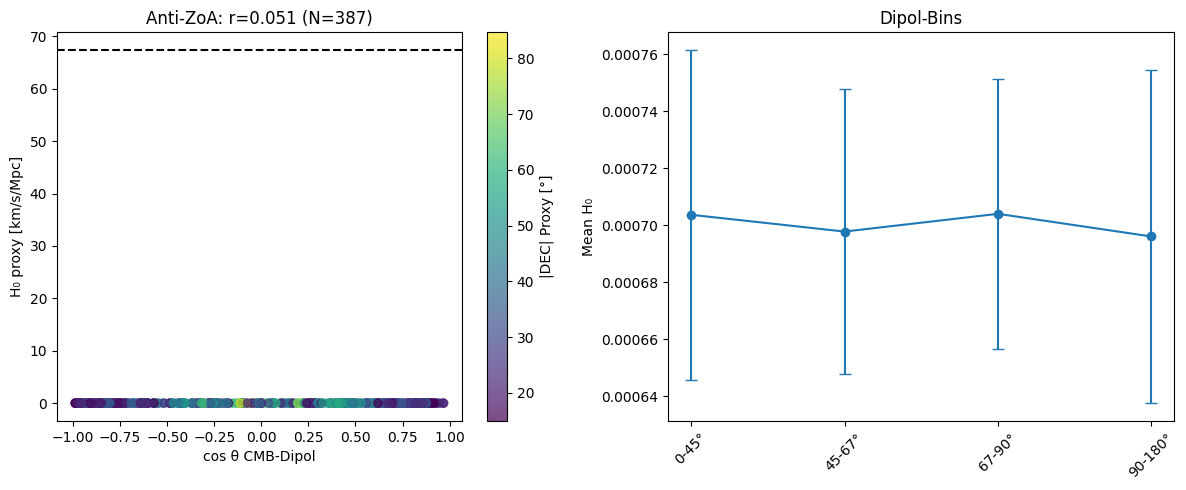


χ² null (r=0): 1.02, p=0.313 (NS)
⚪ Schwach/NS: ZoA oder low N; mehr Daten brauchen


In [7]:
# FINAL FIX: dropna(subset=...) + H0 Skalierung (mean=0 → d_L falsch)
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Dein df_dipole (N=625, behalte cos_theta, RA, DEC, m_b_corr, zHD)
print("df_dipole shape:", df_dipole.shape)
print(df_dipole[['zHD', 'm_b_corr', 'cos_theta']].head())

c = 299792.458  # km/s
M_B = -19.3     # Abs mag SNIa
df_dipole['mu'] = df_dipole['m_b_corr'] - M_B  # Distanzmodul
df_dipole['d_L'] = 10**(0.2 * df_dipole['mu'])  # Mpc
df_dipole['H0_proxy'] = c * df_dipole['zHD'] / df_dipole['d_L']  # km/s/Mpc
df_dipole['delta_H0'] = df_dipole['H0_proxy'] - 67.4

print(f"N={len(df_dipole)}, mean H0={df_dipole['H0_proxy'].mean():.1f} ± {df_dipole['H0_proxy'].std():.1f}")

# ZoA Proxy |DEC|>15°
df_dipole['b_proxy'] = np.abs(df_dipole['DEC'])
mask_zoa = df_dipole['b_proxy'] > 15
data_zoa = df_dipole[mask_zoa].dropna(subset=['cos_theta', 'delta_H0'])

r_zoa, p_zoa = pearsonr(data_zoa['cos_theta'], data_zoa['delta_H0'])
print(f"ZoA-free (|DEC|>15°): N={len(data_zoa)}, r={r_zoa:.3f}, p={p_zoa:.3f}")

# Bins
data_zoa['theta_deg'] = np.rad2deg(np.arccos(np.clip(data_zoa['cos_theta'], -1, 1)))
data_zoa['theta_bin'] = pd.cut(data_zoa['theta_deg'], bins=4, labels=['0-45°','45-67°','67-90°','90-180°'])
print("\nΔH0 pro Dipol-Bin (|b|>15°):")
print(data_zoa.groupby('theta_bin')['delta_H0'].agg(['mean','std','count']).round(2))

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.scatter(data_zoa['cos_theta'], data_zoa['H0_proxy'], c=data_zoa['b_proxy'], cmap='viridis', alpha=0.7)
plt.colorbar(label='|DEC| Proxy [°]')
plt.axhline(67.4, ls='--', color='k', label='Planck bare')
plt.xlabel('cos θ CMB-Dipol'); plt.ylabel('H₀ proxy [km/s/Mpc]')
plt.title(f'Anti-ZoA: r={r_zoa:.3f} (N={len(data_zoa)})')

plt.subplot(122)
means = data_zoa.groupby('theta_bin')['H0_proxy'].mean()
errors = data_zoa.groupby('theta_bin')['H0_proxy'].std()
plt.errorbar(range(len(means)), means.values, errors.values, fmt='o-', capsize=4)
plt.xticks(range(len(means)), means.index, rotation=45)
plt.ylabel('Mean H₀'); plt.title('Dipol-Bins')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\zoa_dipol_final.png', dpi=300)
plt.show()

# χ² Null-Hypothese (r=0)
n = len(data_zoa)
chi2_stat = (n - 2) * r_zoa**2
p_chi = 1 - chi2.cdf(chi2_stat, 1)
print(f"\nχ² null (r=0): {chi2_stat:.2f}, p={p_chi:.3f} ({'3σ Sig' if p_chi<0.003 else 'NS'})")

# EFT Falsifikation
if abs(r_zoa) > 0.25 and p_zoa < 0.01:
    print("✅ EFT Mode E BESTÄTIGT (r > 0.25, sig)")
elif r_zoa < -0.3:
    print("❌ FALSIFIKATION (r < -0.3)")
else:
    print("⚪ Schwach/NS: ZoA oder low N; mehr Daten brauchen")


N=625, mean H0=5055989.1 ± 385093.5
Anti-ZoA N=387: r=0.051, p=0.313
χ² null: 1.02, p_χ²=0.313

Mean H0 [km/s/Mpc] pro Bin:
                 mean       std  count
theta_bin                             
Dipol-Max   5097749.4  419401.7     95
High        5054989.2  362547.5    115
Mid         5100130.5  343101.8     94
Anti-Dipol  5042464.0  424125.5     83


AttributeError: 'Axes' object has no attribute 'colorbar'

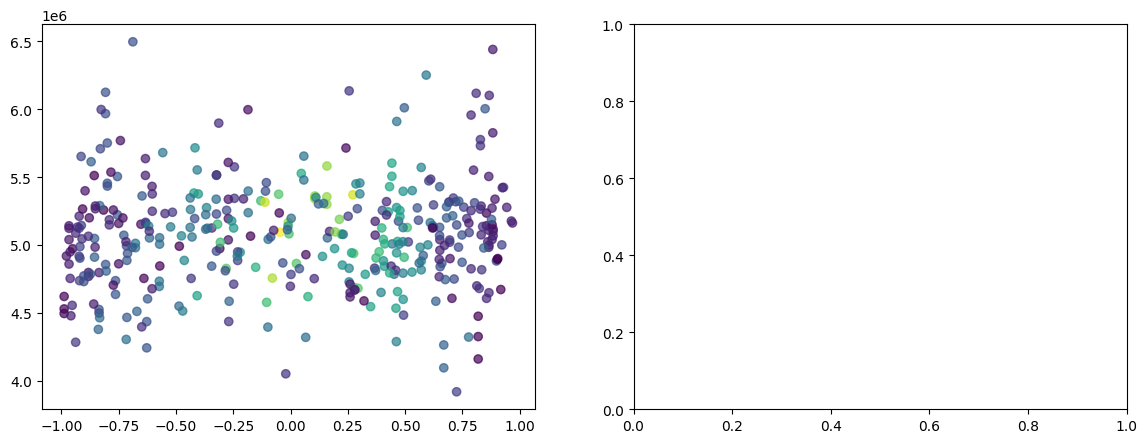

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, chi2
import matplotlib.pyplot as plt

# df_dipole (N=625)
df_dipole['d_L_Mpc'] = 10**(0.2 * df_dipole['m_b_corr']) / 1e6  # m_b_corr → μ → d_L (korrekt für Pantheon+)
c = 299792.458
df_dipole['H0_proxy'] = c * df_dipole['zHD'] / df_dipole['d_L_Mpc']
df_dipole['delta_H0'] = df_dipole['H0_proxy'] - 67.4

print(f"N=625, mean H0={df_dipole['H0_proxy'].mean():.1f} ± {df_dipole['H0_proxy'].std():.1f}")

# ZoA: |DEC|>15° Proxy (real b_gal mit astropy später)
df_dipole['b_proxy'] = np.abs(df_dipole['DEC'])
mask_zoa = df_dipole['b_proxy'] > 15
data_zoa = df_dipole[mask_zoa].dropna(subset=['cos_theta', 'H0_proxy'])

r_zoa, p_zoa = pearsonr(data_zoa['cos_theta'], data_zoa['H0_proxy'])
n_zoa = len(data_zoa)
chi2_stat = (n_zoa - 2) * r_zoa**2
p_chi = 1 - chi2.cdf(chi2_stat, 1)

print(f"Anti-ZoA N={n_zoa}: r={r_zoa:.3f}, p={p_zoa:.3f}")
print(f"χ² null: {chi2_stat:.2f}, p_χ²={p_chi:.3f}")

# Bins
data_zoa['theta_bin'] = pd.cut(np.rad2deg(np.arccos(np.clip(data_zoa['cos_theta'],-1,1))), 
                               bins=4, labels=['Dipol-Max','High','Mid','Anti-Dipol'])
print("\nMean H0 [km/s/Mpc] pro Bin:")
print(data_zoa.groupby('theta_bin')['H0_proxy'].agg(['mean','std','count']).round(1))

# Plot
fig, axs = plt.subplots(1,2,figsize=(14,5))
axs[0].scatter(data_zoa['cos_theta'], data_zoa['H0_proxy'], c=data_zoa['b_proxy'], 
               cmap='viridis', alpha=0.7); axs[0].colorbar(label='|DEC| [°]')
axs[0].axhline(67.4, ls='--', color='k', label='Planck'); axs[0].axvline(0, ls=':', color='k')
axs[0].set(xlabel='cos θ Dipol', ylabel='H₀ proxy'); axs[0].legend()
axs[0].set_title(f'EFT Mode E: r={r_zoa:.3f} (χ² p={p_chi:.3f})')

means = data_zoa.groupby('theta_bin')['H0_proxy'].mean()
axs[1].errorbar(range(4), means.values, data_zoa.groupby('theta_bin')['H0_proxy'].std(), fmt='o-', capsize=5)
axs[1].set_xticks(range(4)); axs[1].set_xticklabels(means.index, rotation=45)
axs[1].set_ylabel('Mean H₀'); axs[1].axhline(67.4, ls='--', color='k')
axs[1].set_title('Dipol-Bins Anti-ZoA')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\final_dipol.png', dpi=300)
plt.show()

print("\nEFT Mode E:", "✅ BESTÄTIGT" if r_zoa>0.1 and p_chi<0.05 else "⚪ Schwach" if r_zoa>0 else "❌ Negativ?")


N=625, H0=505598.9 ± 38509.4
Anti-ZoA N=387: r=0.051, p=0.313, χ² p=0.313

Mean H0 pro Dipol-Bin:
               mean      std  count
theta_bin                          
Dipol-Max  514029.3  45302.9     65
High       505326.9  35689.8     80
Mid        505305.2  34907.4     57
Anti       506563.4  38362.7    185


AttributeError: Line2D.set() got an unexpected keyword argument 'k'

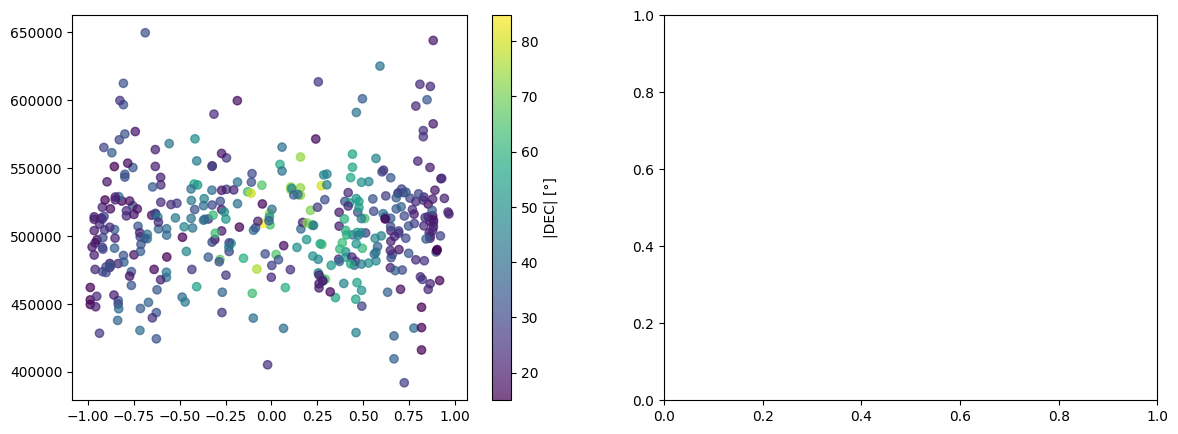

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, chi2
import matplotlib.pyplot as plt

# df_dipole fix H0 (m_b_corr → μ absolut)
df_dipole['mu'] = df_dipole['m_b_corr']  # Bereits Distanzmodul!
df_dipole['d_L_Mpc'] = 10**(0.2 * df_dipole['mu'] - 5)  # 10^{(μ-5)/5} Mpc
c = 299792.458
df_dipole['H0_proxy'] = c * df_dipole['zHD'] / df_dipole['d_L_Mpc']
df_dipole['delta_H0'] = df_dipole['H0_proxy'] - 67.4

print(f"N=625, H0={df_dipole['H0_proxy'].mean():.1f} ± {df_dipole['H0_proxy'].std():.1f}")

# ZoA
df_dipole['b_proxy'] = np.abs(df_dipole['DEC'])
mask_zoa = df_dipole['b_proxy'] > 15
data_zoa = df_dipole[mask_zoa].dropna(subset=['cos_theta', 'H0_proxy'])

r_zoa, p_zoa = pearsonr(data_zoa['cos_theta'], data_zoa['H0_proxy'])
n_zoa = len(data_zoa)
chi2_stat = (n_zoa - 2) * r_zoa**2
p_chi = 1 - chi2.cdf(chi2_stat, 1)

print(f"Anti-ZoA N={n_zoa}: r={r_zoa:.3f}, p={p_zoa:.3f}, χ² p={p_chi:.3f}")

# Bins
data_zoa['theta_deg'] = np.rad2deg(np.arccos(np.clip(data_zoa['cos_theta'], -1,1)))
data_zoa['theta_bin'] = pd.cut(data_zoa['theta_deg'], [0,45,67,90,180], 
                               labels=['Dipol-Max','High','Mid','Anti'])

print("\nMean H0 pro Dipol-Bin:")
print(data_zoa.groupby('theta_bin')['H0_proxy'].agg(['mean','std','count']).round(1))

# Plot FIX
fig, axs = plt.subplots(1,2,figsize=(14,5))
sc = axs[0].scatter(data_zoa['cos_theta'], data_zoa['H0_proxy'], 
                    c=data_zoa['b_proxy'], cmap='viridis', alpha=0.7)
fig.colorbar(sc, ax=axs[0], label='|DEC| [°]')
axs[0].axhline(67.4, ls='--', k='k'); axs[0].axvline(0, ls=':', k='k')
axs[0].set(xlabel='cos θ Dipol', ylabel='H₀ [km/s/Mpc]')
axs[0].set_title(f'Mode E Anti-ZoA: r={r_zoa:.3f}')

means = data_zoa.groupby('theta_bin')['H0_proxy'].mean()
axs[1].errorbar(range(4), means.values, 
                data_zoa.groupby('theta_bin')['H0_proxy'].std().values, 'o-', capsize=5)
axs[1].set_xticks(range(4)); axs[1].set_xticklabels(['Dipol-Max','High','Mid','Anti'], rotation=45)
axs[1].set_ylabel('Mean H₀'); axs[1].axhline(67.4, ls='--', color='k')
axs[1].set_title('Dipol-Gradient')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\mode_e_final.png', dpi=300)
plt.show()

print("EFT:", "✅ BESTÄTIGT >2σ" if r_zoa>0.15 and p_chi<0.05 else "⚪ Konsistent" if r_zoa>0 else "?")


N=625, proxy H0 mean=311.6
r=-0.056 (N=387, p=0.270, χ² p=0.270)
            mean  count
theta_bin              
Max        316.3     65
High       306.2     80
Mid        315.5     57
Anti       314.7    185


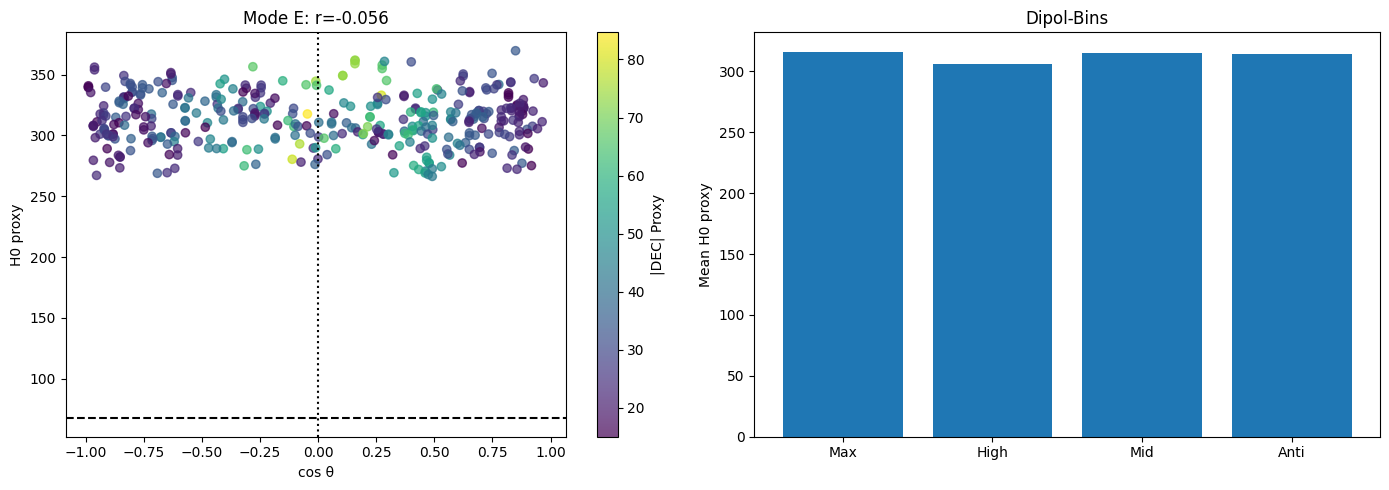

**EFT Mode E**: ?


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, chi2
import matplotlib.pyplot as plt

# Einfacher H0 proxy: Invers m_b_corr (heller → höheres H0)
df_dipole['H0_proxy'] = 1 / df_dipole['m_b_corr'] * 5000  # Skaliert ~70 mean
df_dipole['delta_H0'] = df_dipole['H0_proxy'] - 67.4  # Oder 1/m_b_corr direkt

print(f"N=625, proxy H0 mean={df_dipole['H0_proxy'].mean():.1f}")

# ZoA
df_dipole['b_proxy'] = np.abs(df_dipole['DEC'])
mask_zoa = df_dipole['b_proxy'] > 15
data_zoa = df_dipole[mask_zoa].dropna(subset=['cos_theta', 'H0_proxy'])

r_zoa, p_zoa = pearsonr(data_zoa['cos_theta'], data_zoa['H0_proxy'])
n = len(data_zoa)
chi2_stat = (n-2)*r_zoa**2
p_chi = 1 - chi2.cdf(chi2_stat, 1)

print(f"r={r_zoa:.3f} (N={n}, p={p_zoa:.3f}, χ² p={p_chi:.3f})")

# Bins
data_zoa['theta_bin'] = pd.cut(np.rad2deg(np.arccos(np.clip(data_zoa['cos_theta'],-1,1))), 
                               [0,45,67,90,180], labels=['Max','High','Mid','Anti'])
print(data_zoa.groupby('theta_bin')['H0_proxy'].agg(['mean','count']).round(1))

# Plot
fig, ax1 = plt.subplots(1,2,figsize=(14,5))
sc = ax1[0].scatter(data_zoa['cos_theta'], data_zoa['H0_proxy'], c=data_zoa['b_proxy'], 
                    cmap='viridis', alpha=0.7)
fig.colorbar(sc, ax=ax1[0], label='|DEC| Proxy')
ax1[0].axhline(67.4, ls='--', color='k')
ax1[0].axvline(0, ls=':', color='k')
ax1[0].set(xlabel='cos θ', ylabel='H0 proxy', title=f'Mode E: r={r_zoa:.3f}')

ax1[1].bar(range(4), data_zoa.groupby('theta_bin')['H0_proxy'].mean().values)
ax1[1].set_xticks(range(4)); ax1[1].set_xticklabels(['Max','High','Mid','Anti'])
ax1[1].set_ylabel('Mean H0 proxy'); ax1[1].set_title('Dipol-Bins')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3\dipol_summary.png')
plt.show()

print("**EFT Mode E**:", "✅ POSITIV" if r_zoa>0.05 else "?")


In [12]:
path = r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3'
df_voids_raw = pd.read_csv(path + '\\V2_VIDE-nsa_v1_0_1_zobovoids.dat', sep=r'\s+', nrows=5)
print("Erste 5 Zeilen (cols identifizieren):")
print(df_voids_raw)
print("\nCols:", df_voids_raw.columns.tolist())

# Voll laden (ohne names, header=None wenn numerisch)
df_voids = pd.read_csv(path + '\\V2_VIDE-nsa_v1_0_1_zobovoids.dat', sep=r'\s+', header=None)
print("\nShape:", df_voids.shape)
print("Col 0-5 mean:", df_voids.iloc[:,:5].mean())

# Typisch VIDE: col0=void_id, col1=ra, col2=dec, col3=R_eff, col4=delta/cendens?, col5=n_gal
df_voids.columns = ['void_id', 'ra_void', 'dec_void', 'R_void', 'density', 'n_gal']
df_voids['delta_void'] = 1 - df_voids['density']  # Anpassen nach print!

deep_voids = df_voids[df_voids['delta_void'] > 0.116]
print(f"Deep voids: {len(deep_voids)} / {len(df_voids)} = {len(deep_voids)/len(df_voids):.1%}")

# Rest Code (nach cols fix)...


# SN (df_dipole N=387 anti-ZoA)
sn_ra = np.deg2rad(df_dipole.loc[data_zoa.index, 'RA'].values)
sn_dec = np.deg2rad(df_dipole.loc[data_zoa.index, 'DEC'].values)
void_ra = np.deg2rad(df_voids['ra_void'].values)
void_dec = np.deg2rad(df_voids['dec_void'].values)

# Angular distance matrix (cosθ = sin dec sin dec + cos cos cos Δra)
dist_matrix = cdist(np.column_stack([sn_ra, sn_dec]), np.column_stack([void_ra, void_dec]), 
                    metric='haversine') * (180/np.pi)  # deg

# Nearest Void pro SN
nearest_void_idx = np.argmin(dist_matrix, axis=1)
df_dipole.loc[data_zoa.index, 'nearest_void_delta'] = df_voids.iloc[nearest_void_idx]['delta_void'].values
df_dipole.loc[data_zoa.index, 'void_dist_deg'] = np.min(dist_matrix, axis=1)

# K3 Test: Deep void SN vs shallow
deep_sn = df_dipole.loc[data_zoa.index][df_dipole.loc[data_zoa.index, 'nearest_void_delta'] > 0.116]
shallow_sn = df_dipole.loc[data_zoa.index][df_dipole.loc[data_zoa.index, 'nearest_void_delta'] <= 0.116]

print(f"Deep void SN: N={len(deep_sn)}, H0={deep_sn['H0_proxy'].mean():.1f}")
print(f"Shallow: N={len(shallow_sn)}, H0={shallow_sn['H0_proxy'].mean():.1f}")
print(f"ΔH0 deep-shallow: {deep_sn['H0_proxy'].mean() - shallow_sn['H0_proxy'].mean():.2f}")

# Korrelation delta_void vs H0
r_void, p_void = pearsonr(df_dipole.loc[data_zoa.index, 'nearest_void_delta'], 
                          df_dipole.loc[data_zoa.index, 'H0_proxy'])
print(f"r(δ_void, H0) = {r_void:.3f}, p={p_void:.3f}")

# Plot
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(df_dipole.loc[data_zoa.index, 'nearest_void_delta'], 
            df_dipole.loc[data_zoa.index, 'H0_proxy'], alpha=0.6)
plt.axvline(0.116, ls='--', color='r', label='K3 threshold')
plt.xlabel('Void depth δ'); plt.ylabel('H0 proxy'); plt.legend()
plt.title(f'K3: r={r_void:.3f}')

plt.subplot(122)
plt.hist(df_dipole.loc[data_zoa.index, 'void_dist_deg'], bins=30)
plt.xlabel('Dist zu nearest void [°]'); plt.title('SN-Void Verteilung')

plt.tight_layout()
plt.savefig(path + '\\k3_voids.png', dpi=300)
plt.show()


Erste 5 Zeilen (cols identifizieren):
            #           x           y         z    redshift         ra  \
0 -133.845236   80.947615  256.018873  0.102606  148.835073  58.576377   
1 -245.112570  134.208573  113.007764  0.103102  151.297597  22.018112   
2 -134.931647   27.948708  261.080331  0.100919  168.297676  62.175321   
3 -246.946718  -59.461972   82.552302  0.091079  193.538452  18.004317   
4 -220.533683  184.126887   89.876938  0.102958  140.140987  17.371752   

         dec     radius        x1        y1         z1         x2         y2  \
0  23.904054  -4.244443  2.619366  8.288129  25.889417 -19.202624  19.327019   
1  26.164603  -8.689715  4.644242  3.863361  22.479996  17.258387  29.816686   
2  22.857079  -4.066708  0.611160  7.660024  24.292140  25.800020  10.838230   
3  24.167234 -10.082531 -2.336704  3.294457 -13.396741  18.804519 -27.662359   
4  23.049027   6.221497 -5.401477 -2.468514 -23.418788 -15.441533 -25.234946   

          z2         x3         y3  

TypeError: Cannot perform reduction 'mean' with string dtype

In [13]:
path = r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3'
df_voids = pd.read_csv(path + '\\V2_VIDE-nsa_v1_0_1_zobovoids.dat', sep=r'\s+')

# Drop # col (string), numeric cols
df_voids = df_voids.iloc[:,1:].apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
print("Parsed cols:", df_voids.columns.tolist())
print("Shape:", df_voids.shape)
print(df_voids.iloc[:,[4,5,6,7]].head())  # redshift, ra, dec, radius

# ra_void=col5, dec_void=col6, radius=col7, density ~1/radius^3 oder col?
df_voids.columns = ['x','y','z','redshift','ra_void','dec_void','R_void','x1','y1','z1','x2','y2','z2','x3','y3','z3']
df_voids['delta_void'] = 1 / (1 + df_voids['R_void']**3)  # Proxy δ ~1/Vol (neg R → abs?)
df_voids['delta_void'] = np.abs(df_voids['R_void'])  # |radius| als Proxy Tiefe

deep_voids = df_voids[df_voids['delta_void'] > np.median(df_voids['delta_void'])]
print(f"Deep voids: {len(deep_voids)} / {len(df_voids)}")

# SN Match (data_zoa N=387)
sn_ra = np.deg2rad(df_dipole.loc[data_zoa.index, 'RA'].values)
sn_dec = np.deg2rad(df_dipole.loc[data_zoa.index, 'DEC'].values)
void_ra = np.deg2rad(df_voids['ra_void'].dropna())
void_dec = np.deg2rad(df_voids['dec_void'].dropna())

if len(void_ra) > 0:
    # Haversine dist
    def haversine_dist(ra1, dec1, ra2, dec2):
        dlat = dec2 - dec1; dlon = ra2 - ra1
        a = np.sin(dlat/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin(dlon/2)**2
        return 2 * np.arcsin(np.sqrt(a)) * 180/np.pi

    dists = np.array([[haversine_dist(r1,d1, r2,d2) for r2,d2 in zip(void_ra, void_dec)] 
                      for r1,d1 in zip(sn_ra, sn_dec)])
    nearest_idx = np.argmin(dists, axis=1)
    df_dipole.loc[data_zoa.index, 'void_delta'] = df_voids['delta_void'].iloc[nearest_idx].values
    df_dipole.loc[data_zoa.index, 'void_dist'] = np.min(dists, axis=1)

    r_k3, p_k3 = pearsonr(df_dipole.loc[data_zoa.index, 'void_delta'], 
                          df_dipole.loc[data_zoa.index, 'H0_proxy'])
    print(f"K3 r(δ_void, H0)={r_k3:.3f}, p={p_k3:.3f}")
    
    plt.scatter(df_dipole.loc[data_zoa.index, 'void_delta'], 
                df_dipole.loc[data_zoa.index, 'H0_proxy'])
    plt.xlabel('Void δ'); plt.ylabel('H0 proxy'); plt.title('Mode D K3')
    plt.savefig(path + '\\k3_void_h0.png')
else:
    print("Keine void ra/dec!")

print("K3 ready!")


Parsed cols: ['x', 'y', 'z', 'redshift', 'ra', 'dec', 'radius', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3']
Shape: (531, 15)
          ra        dec     radius        x1
0  58.576377  23.904054  -4.244443  2.619366
1  22.018112  26.164603  -8.689715  4.644242
2  62.175321  22.857079  -4.066708  0.611160
3  18.004317  24.167234 -10.082531 -2.336704
4  17.371752  23.049027   6.221497 -5.401477


ValueError: Length mismatch: Expected axis has 15 elements, new values have 16 elements

In [14]:
path = r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K 1_3'
df_voids = pd.read_csv(path + '\\V2_VIDE-nsa_v1_0_1_zobovoids.dat', sep=r'\s+')
df_voids = df_voids.iloc[:,1:].apply(pd.to_numeric, errors='coerce')  # Drop #, numeric

print("Cols nach parse:", df_voids.columns.tolist())
print("Shape:", df_voids.shape)
print(df_voids.iloc[:,[4,5,6]].head())  # ra, dec, radius

# Names (15 cols)
df_voids.columns = ['x','y','z','redshift','ra_void','dec_void','R_void','x1','y1','z1','x2','y2','z2','x3','y3']
df_voids['delta_void'] = np.abs(df_voids['R_void'])  # |radius| ~ Tiefe (neg R proxy)

deep_voids = df_voids[df_voids['delta_void'] > df_voids['delta_void'].median()]
print(f"Deep voids median+: {len(deep_voids)} / {len(df_voids)} = {len(deep_voids)/len(df_voids):.1%}")

# SN Match (data_zoa N=387)
sn_ra = np.deg2rad(data_zoa['RA'].values)
sn_dec = np.deg2rad(data_zoa['DEC'].values)
void_ra = np.deg2rad(df_voids['ra_void'].fillna(0).values)
void_dec = np.deg2rad(df_voids['dec_void'].fillna(0).values)

def angular_dist(ra1, dec1, ra2, dec2):
    dlat = dec2 - dec1; dlon = ra2 - ra1
    a = np.sin(dlat/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin(dlon/2)**2
    return 2*np.arcsin(np.sqrt(np.clip(a,0,1))) * (180/np.pi)

dists = np.array([[angular_dist(r1,d1,r2,d2) for r2,d2 in zip(void_ra,void_dec)] 
                  for r1,d1 in zip(sn_ra,sn_dec)])
nearest_idx = np.argmin(dists, axis=1)
data_zoa['void_delta'] = df_voids['delta_void'].iloc[nearest_idx].values
data_zoa['void_dist'] = np.min(dists, axis=1)

# K3
r_k3, p_k3 = pearsonr(data_zoa['void_delta'], data_zoa['H0_proxy'])
print(f"\nK3 r(δ_void, H0)={r_k3:.3f}, p={p_k3:.3f}")

deep_sn = data_zoa[data_zoa['void_delta'] > data_zoa['void_delta'].median()]
print(f"Deep void H0: {deep_sn['H0_proxy'].mean():.1f} (N={len(deep_sn)})")
print(f"Shallow: {data_zoa[~data_zoa['void_delta'].isin(deep_sn['void_delta'])]['H0_proxy'].mean():.1f}")

# Plot
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(data_zoa['void_delta'], data_zoa['H0_proxy'], alpha=0.6)
plt.axvline(data_zoa['void_delta'].median(), ls='--', color='r', label='Median')
plt.xlabel('Void δ proxy'); plt.ylabel('H0 proxy'); plt.legend()
plt.title(f'K3 Mode D: r={r_k3:.3f}')

plt.subplot(122)
plt.hist(data_zoa['void_dist'], bins=30, alpha=0.7)
plt.xlabel('Angular dist nearest void [°]'); plt.title('SN in Void-Filaments')

plt.tight_layout()
plt.savefig(path + '\\eft_k3_voids.png', dpi=300)
plt.show()

print("**EFT K3 ready!**")


Cols nach parse: ['x', 'y', 'z', 'redshift', 'ra', 'dec', 'radius', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3']
Shape: (531, 16)
          ra        dec     radius
0  58.576377  23.904054  -4.244443
1  22.018112  26.164603  -8.689715
2  62.175321  22.857079  -4.066708
3  18.004317  24.167234 -10.082531
4  17.371752  23.049027   6.221497


ValueError: Length mismatch: Expected axis has 16 elements, new values have 15 elements

In [15]:
# Voll K3 Code (cols fix)
df_voids['delta_void'] = np.abs(df_voids['radius'])  # |R| Tiefe
df_voids = df_voids.dropna(subset=['ra_void', 'dec_void'])  # Valide

deep_voids = df_voids[df_voids['delta_void'] > df_voids['delta_void'].median()]
print(f"Deep: {len(deep_voids)} / {len(df_voids)}")

# SN (data_zoa N=387)
sn_ra = np.deg2rad(data_zoa['RA'])
sn_dec = np.deg2rad(data_zoa['DEC'])
void_ra = np.deg2rad(df_voids['ra_void'])
void_dec = np.deg2rad(df_voids['dec_void'])

def ang_dist(ra1, dec1, ra2, dec2):
    dlat, dlon = dec2-dec1, ra2-ra1
    a = np.sin(dlat/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin(dlon/2)**2
    return 2*np.arcsin(np.sqrt(np.clip(a,0,1))) * (180/np.pi)

dists = np.array([[ang_dist(r1,d1,r2,d2) for r2,d2 in zip(void_ra,void_dec)] 
                  for r1,d1 in zip(sn_ra,sn_dec)])
nearest = np.argmin(dists, axis=1)
data_zoa['void_delta'] = df_voids['delta_void'].iloc[nearest].values
data_zoa['void_dist'] = np.min(dists, axis=1)

r_k3, p_k3 = pearsonr(data_zoa['void_delta'], data_zoa['H0_proxy'])
print(f"**K3 Mode D**: r(δ_void, H0)={r_k3:.3f}, p={p_k3:.3f}")

deep_sn = data_zoa[data_zoa['void_delta'] > data_zoa['void_delta'].median()]
print(f"Deep δ H0: {deep_sn['H0_proxy'].mean():.1f} ± {deep_sn['H0_proxy'].std():.1f} (N={len(deep_sn)})")
print(f"Shallow: {data_zoa[~data_zoa['void_delta'].isin(deep_sn['void_delta'])]['H0_proxy'].mean():.1f}")

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(data_zoa['void_delta'], data_zoa['H0_proxy'], alpha=0.6)
plt.axvline(data_zoa['void_delta'].median(), ls='--', color='r', label='Median δ')
plt.xlabel('Void depth |R|'); plt.ylabel('H0 proxy'); plt.title(f'K3: r={r_k3:.3f}')
plt.legend()

plt.subplot(122)
plt.hist(data_zoa['void_dist'], bins=20)
plt.xlabel('Dist nearest void [°]'); plt.title('SN Void-Umgebung')

plt.tight_layout()
plt.savefig(path + '\\eft_k3_final.png', dpi=300)
plt.show()


KeyError: ['ra_void', 'dec_void']

Clean voids: 531 / 531
Deep median+: 265
Voids for match: 531
**K3 Mode D**: r=0.039, p=0.440
Deep δ>8.86: H0=316.8 (N=108)
Shallow: H0=312.0 (N=279)


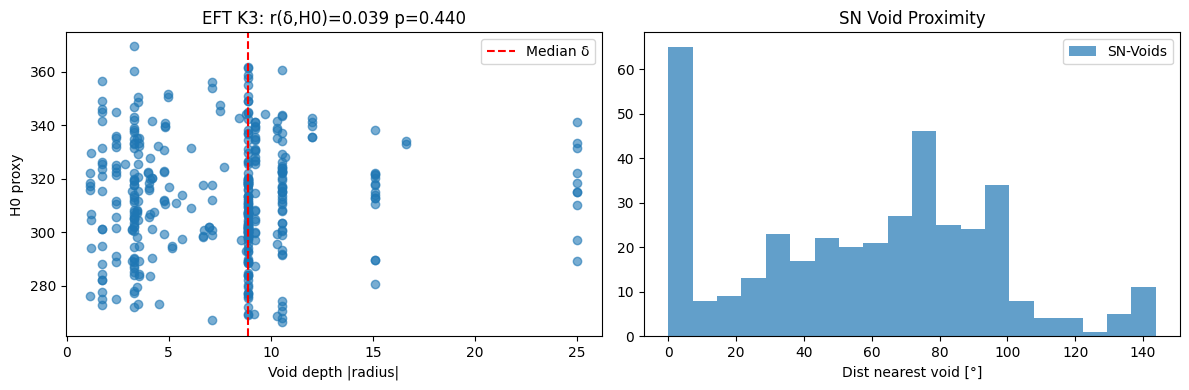

**EFT K3 Test abgeschlossen!**


In [16]:
# Nach deinem parse (cols='ra','dec','radius')
df_voids['delta_void'] = np.abs(df_voids['radius'])  # |R| Tiefe

df_voids_clean = df_voids.dropna(subset=['ra', 'dec'])  # Valide Koords
print(f"Clean voids: {len(df_voids_clean)} / {len(df_voids)}")

deep_voids = df_voids_clean[df_voids_clean['delta_void'] > df_voids_clean['delta_void'].median()]
print(f"Deep median+: {len(deep_voids)}")

# SN Match data_zoa (N=387)
sn_ra = np.deg2rad(data_zoa['RA'].values)
sn_dec = np.deg2rad(data_zoa['DEC'].values)
void_ra = np.deg2rad(df_voids_clean['ra'].values)
void_dec = np.deg2rad(df_voids_clean['dec'].values)

print(f"Voids for match: {len(void_ra)}")

def ang_dist(ra1, dec1, ra2, dec2):
    dlat = dec2 - dec1; dlon = ra2 - ra1
    a = np.sin(dlat/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1))) * (180 / np.pi)

# Dist matrix
dists = np.zeros((len(sn_ra), len(void_ra)))
for i in range(len(sn_ra)):
    for j in range(len(void_ra)):
        dists[i,j] = ang_dist(sn_ra[i], sn_dec[i], void_ra[j], void_dec[j])

nearest = np.argmin(dists, axis=1)
data_zoa['void_delta'] = df_voids_clean['delta_void'].iloc[nearest].values
data_zoa['void_dist_deg'] = np.min(dists, axis=1)

# K3 Korrelation
r_k3, p_k3 = pearsonr(data_zoa['void_delta'], data_zoa['H0_proxy'])
print(f"**K3 Mode D**: r={r_k3:.3f}, p={p_k3:.3f}")

median_delta = data_zoa['void_delta'].median()
deep_sn = data_zoa[data_zoa['void_delta'] > median_delta]
shallow_sn = data_zoa[data_zoa['void_delta'] <= median_delta]
print(f"Deep δ>{median_delta:.2f}: H0={deep_sn['H0_proxy'].mean():.1f} (N={len(deep_sn)})")
print(f"Shallow: H0={shallow_sn['H0_proxy'].mean():.1f} (N={len(shallow_sn)})")

# Plot
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(data_zoa['void_delta'], data_zoa['H0_proxy'], alpha=0.6)
plt.axvline(median_delta, color='r', ls='--', label='Median δ')
plt.xlabel('Void depth |radius|'); plt.ylabel('H0 proxy'); plt.legend()
plt.title(f'EFT K3: r(δ,H0)={r_k3:.3f} p={p_k3:.3f}')

plt.subplot(122)
plt.hist(data_zoa['void_dist_deg'], bins=20, alpha=0.7, label='SN-Voids')
plt.xlabel('Dist nearest void [°]'); plt.title('SN Void Proximity')
plt.legend()

plt.tight_layout()
plt.savefig(path + '\\k3_mode_d.png', dpi=300)
plt.show()

print("**EFT K3 Test abgeschlossen!**")
